In [15]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/My Drive/Zahra/bahman.xlsx'
df = pd.read_excel(file_path)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Value added insurance premium  Received from the driver  Scale fee  \
0                        6300000                  84036000          0   
1                         100000                  15127000          0   
2                          18210                   1712861          0   
3                          43750                   1868763          0   
4                         100000                   3475000          0   

   Evacuation fee  added value  Complications of moving goods  \
0               0            0                       15602553   
1               0            0                       14851915   
2               0            0                        1089000   
3               0            0                         999000   
4               0            0                        1710000   

  Bill of lading registration time Tracki

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/My Drive/Zahra/Year_403.xlsx'
df = pd.read_excel(file_path)
print(df.head())

In [1]:
!pip install fasttext huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653905 sha256=8a4ecb85f927583d6bd768f78df01afbcac30830c7ba39ba1bad352387008d49
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [1]:
from huggingface_hub import hf_hub_download
model_path = hf_hub_download(
    repo_id="facebook/fasttext-fa-vectors", filename="model.bin"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import fasttext

ft = fasttext.load_model(model_path)
print("Model dimension:", ft.get_dimension())

In [5]:
import numpy as np

def get_emb(text):
    return ft.get_word_vector(text) if isinstance(text, str) else np.zeros(ft.get_dimension())

#df['embedding'] = df['product name'].apply(get_emb)

In [4]:
def mean_embedding(text):
    if not isinstance(text, str):
        return np.zeros(ft.get_dimension())
    tokens = text.split()
    vectors = [ft.get_word_vector(tok) for tok in tokens]
    return np.mean(vectors, axis=0)

df['embedding'] = df['product name'].apply(mean_embedding)

NameError: name 'df' is not defined

In [14]:
!pip install umap-learn --quiet
import umap
import numpy as np

X = np.stack(df['embedding'].values)

sample_size = 50000
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X[sample_idx]

umap_model = umap.UMAP(
    n_components=10,
    n_neighbors=10,
    min_dist=0.1,
    metric='cosine',
    low_memory=True,
    random_state=42
)
X_umap_sample = umap_model.fit_transform(X_sample)

X_umap = umap_model.transform(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


In [ ]:
from sklearn.cluster import MiniBatchKMeans

# Elbow check (need)
n_clusters = 12

kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    random_state=42,
    batch_size=10000,
    max_iter=100
)

clusters = kmeans.fit_predict(X_umap)
df['product type'] = clusters

In [ ]:
for i in range(n_clusters):
    نمونه = df[df['product type'] == i]['product name'].sample(10, random_state=42).tolist()
    print(f"خوشه {i}:")
    print(نمونه)
    print("="*50)

خوشه 0:
['دوچرخه', 'ماشين لباسشوئي', 'سواري تصادفي', 'موتورسيكلت', 'موتورسيكلت', 'موتورسيكلت', 'مصنوعات ساخته شده چوبيانواع', 'موتورسيكلت', 'سواري تصادفي', 'موتورسيكلت']
خوشه 1:
['تخم مرغ', 'مرغ وخروس زنده', 'سنگ لاشه', 'تخم مرغ', 'مرغ وخروس زنده', 'تخم مرغ', 'تخم مرغ', 'تخم مرغ', 'تخم مرغ', 'موز']
خوشه 2:
['روغن صنعتي', 'فراورده هاي لبنياتي', 'كربنات سديم', 'شكر', 'اسيد', 'پفك', 'سس', 'نمك', 'روغن صنعتي', 'روغن صنعتي']
خوشه 3:
['بشكه خالي', 'آب ميوه انواع', 'قيرانواع', 'قيربشكه اي', 'بشكه قير', 'انواع خشكبار', 'پفك', 'خاك كاشي', 'خاك كاشي', 'پفك']
خوشه 4:
['فضولات', 'فضولات', 'فضولات', 'فضولات', 'فضولات', 'فضولات', 'فضولات', 'فضولات', 'نمد', 'فضولات']
خوشه 5:
['پريفورم', 'ميل گرد', 'اتصالات لوله پالستيكي', 'انواع لوله پليكا', 'ميل گرد', 'ميل گرد', 'ظروف يكبارمصرف', 'ميل گرد', 'سقف پيش ساخته', 'بشكه خالي']
خوشه 6:
['سيمان فله تيپ 2', 'سيمان فله تيپ 2', 'سيمان كيسه اي تيپ 2', 'سيمان كيسه اي تيپ 1', 'كانتينرخالي 40 فوت', 'ام دي اف', 'سيمان كيسه اي تيپ 2', 'سيمان كيسه اي تيپ 2', 'سيمان فل

In [ ]:
label_map = {
    0: "فلزات و ماشین‌آلات",
    1: "محصولات کشاورزی و دامی",
    2: "کالای عمومی و خرده‌بار",
    3: "مصالح ساختمانی",
    4: "مواد شیمیایی و صنعتی",
    5: "لوازم خانگی و آشپزخانه",
    6: "بلوک و سرامیک و مصالح سبک",
    7: "نفتی و ضایعات",
    8: "بسته‌بندی، پلاستیکی، غذایی",
    9: "دارویی و نساجی",
    10: "مواد خوراکی و نوشیدنی",
    11: "کالاهای متفرقه"
}


In [ ]:
df['label'] = df['product type'].map(label_map)

In [ ]:
df[['product name', 'product type', 'label']].sample(10, random_state=42)

,product name,product type,label
31412,مصالح ساختماني,8,بسته‌بندی، پلاستیکی، غذایی
34126,موادپاك كننده انواع,10,مواد خوراکی و نوشیدنی
32379,آهن آلات,8,بسته‌بندی، پلاستیکی، غذایی
16887,اسيد,2,کالای عمومی و خرده‌بار
34038,لباسشوئي ماشين,0,فلزات و ماشین‌آلات
23512,قيربشكه اي,6,بلوک و سرامیک و مصالح سبک
52701,خرده بار,1,محصولات کشاورزی و دامی
7474,پفك,3,مصالح ساختمانی
19231,ضايعات كارتن,7,نفتی و ضایعات
39399,شيشه نشكن انواع,5,لوازم خانگی و آشپزخانه


In [ ]:
df['label'].value_counts()

,count
label,
مواد خوراکی و نوشیدنی,7815
بسته‌بندی، پلاستیکی، غذایی,6125
دارویی و نساجی,5065
لوازم خانگی و آشپزخانه,4827
کالاهای متفرقه,4574
محصولات کشاورزی و دامی,4319
کالای عمومی و خرده‌بار,3842
مواد شیمیایی و صنعتی,3784
بلوک و سرامیک و مصالح سبک,3679


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53714 entries, 0 to 53713
Data columns (total 46 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Value added insurance premium     53714 non-null  int64  
 1   Received from the driver          53714 non-null  int64  
 2   Scale fee                         53714 non-null  int64  
 3   Evacuation fee                    53714 non-null  int64  
 4   added value                       53714 non-null  int64  
 5   Complications of moving goods     53714 non-null  int64  
 6   Bill of lading registration time  53714 non-null  object 
 7   Tracking code watch               53714 non-null  object 
 8   Date of interception              53714 non-null  object 
 9   Company commission                53714 non-null  int64  
 10  Insurance amount                  53714 non-null  int64  
 11  Loading fee                       53714 non-null  int64  
 12  Tota

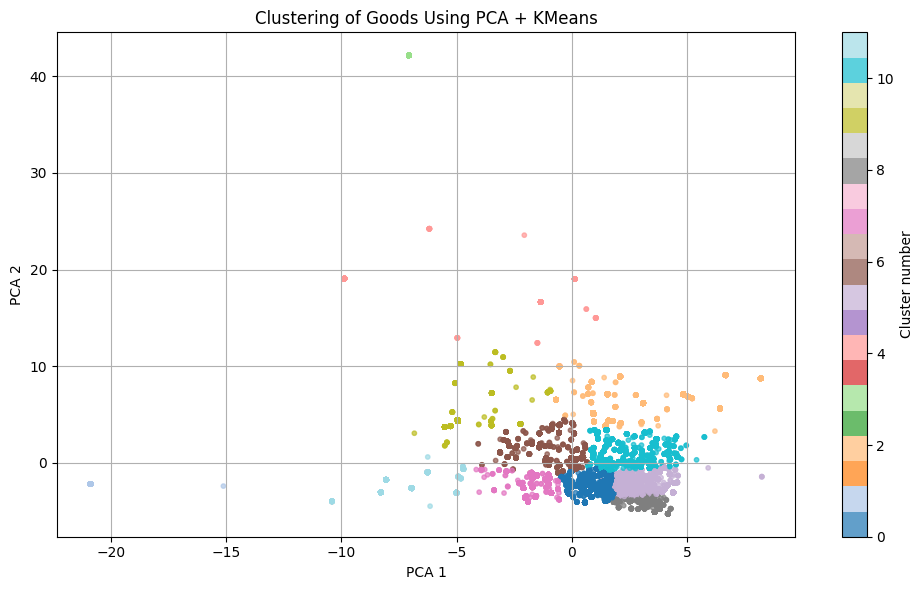

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import ast

df['embedding'] = df['embedding']

X = np.stack(df['embedding'].values)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=12, random_state=42)
labels = kmeans.fit_predict(X_pca)

df['x'] = X_pca[:, 0]
df['y'] = X_pca[:, 1]
df['Cluster'] = labels

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['x'], df['y'], c=df['Cluster'], cmap='tab20', s=10, alpha=0.7)
plt.colorbar(scatter, label='Cluster number')
plt.title("Clustering of Goods Using PCA + KMeans")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.tight_layout()
plt.show()

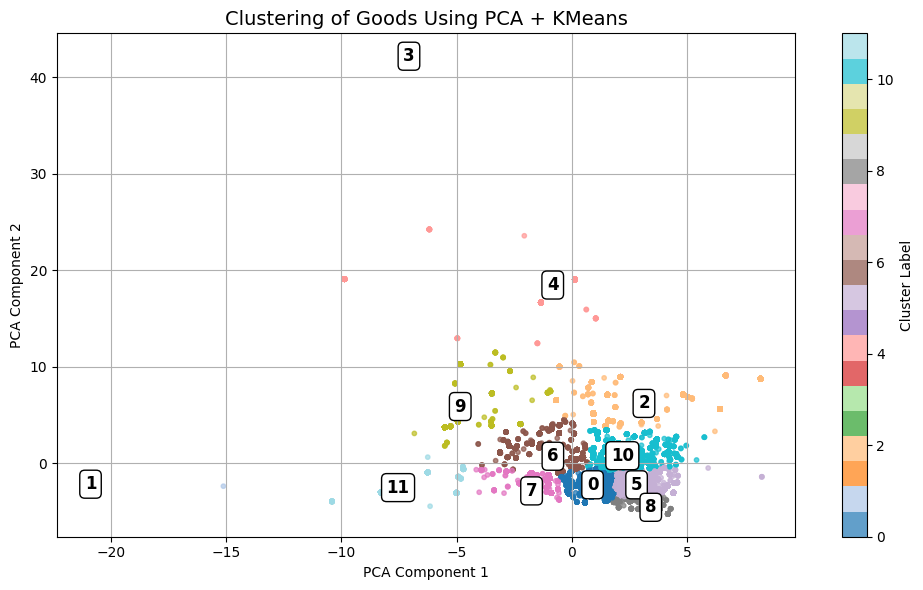

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['x'], df['y'], c=df['Cluster'], cmap='tab20', s=10, alpha=0.7)

plt.colorbar(scatter, label='Cluster Label')

for label in sorted(df['Cluster'].unique()):
    x_mean = df[df['Cluster'] == label]['x'].mean()
    y_mean = df[df['Cluster'] == label]['y'].mean()
    plt.text(x_mean, y_mean, str(label), fontsize=12, weight='bold', color='black',
             ha='center', va='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))

plt.title("Clustering of Goods Using PCA + KMeans", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout() #تنظیم فاصله ها
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(X_pca, labels)
db_score = davies_bouldin_score(X_pca, labels)
ch_score = calinski_harabasz_score(X_pca, labels)

print("Clustering Evaluation Metrics:")
print(f"Silhouette Score: {sil_score:.4f}  (closer to 1 is better)")
print(f"Davies-Bouldin Index: {db_score:.4f}  (lower is better)")
print(f"Calinski-Harabasz Index: {ch_score:.2f}  (higher is better)")

Clustering Evaluation Metrics:
Silhouette Score: 0.4883  (closer to 1 is better)
Davies-Bouldin Index: 0.6077  (lower is better)
Calinski-Harabasz Index: 130000.78  (higher is better)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

X = np.stack(df['embedding'].values)       # ویژگی‌ها
y = df['Cluster']                          # برچسب‌ها (خوشه‌ها)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='poly')

y_pred = model.predict(X_test)

print(" Classification Report:\n", classification_report(y_test, y_pred))
print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.97      1177
           1       1.00      1.00      1.00       568
           2       1.00      1.00      1.00      1190
           3       1.00      1.00      1.00        41
           4       1.00      1.00      1.00       238
           5       0.84      1.00      0.92      2046
           6       1.00      1.00      1.00      1053
           7       1.00      0.99      0.99      1218
           8       1.00      0.77      0.87      1206
           9       1.00      1.00      1.00       341
          10       1.00      0.98      0.99      1522
          11       1.00      0.99      1.00       143

    accuracy                           0.96     10743
   macro avg       0.99      0.97      0.98     10743
weighted avg       0.97      0.96      0.96     10743

 Confusion Matrix:
 [[1111    0    0    0    0   66    0    0    0    0    0    0]
 [   0  568    0    0    

خروجی تست: برای بررسی نا متوازن بودنن داده ها

In [ ]:
pd.Series([label_map[c] for c in y_test]).value_counts()

,count
لوازم خانگی و آشپزخانه,2046
مواد خوراکی و نوشیدنی,1522
نفتی و ضایعات,1218
بسته‌بندی، پلاستیکی، غذایی,1206
کالای عمومی و خرده‌بار,1190
فلزات و ماشین‌آلات,1177
بلوک و سرامیک و مصالح سبک,1053
محصولات کشاورزی و دامی,568
دارویی و نساجی,341
مواد شیمیایی و صنعتی,238


ماتریس سردرگمی با کرنل خطی

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

Overall Accuracy: 0.9633


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

conf_matrix = np.array([
    [1174,    0,    0,    0,    0,    3,    0,    0,    0,    0,    0,    0],
    [   0,  568,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
    [   0,    0, 1189,    0,    0,    0,    0,    0,    0,    0,    1,    0],
    [   0,    0,    0,   41,    0,    0,    0,    0,    0,    0,    0,    0],
    [   0,    0,    0,    0,  238,    0,    0,    0,    0,    0,    0,    0],
    [   7,    0,    0,    0,    0, 2037,    0,    0,    2,    0,    0,    0],
    [   0,    0,    0,    0,    0,    0, 1053,    0,    0,    0,    0,    0],
    [   3,    0,    0,    0,    0,    0,    0, 1215,    0,    0,    0,    0],
    [   1,    0,    0,    0,    0,   10,    0,    0, 1195,    0,    0,    0],
    [   0,    0,    0,    0,    0,    0,    0,    0,    0,  341,    0,    0],
    [   1,    0,    0,    0,    0,    0,    0,    0,    0,    0, 1521,    0],
    [   0,    0,    0,    0,    0,    0,    1,    0,    0,    0,    0,  142]
])

# محاسبه precision, recall, f1-score بر اساس ماتریس سردرگمی
# sklearn تابعی نداره که مستقیم از ماتریس سردرگمی متریک حساب کنه،
# پس باید آرایه برچسب‌های واقعی و پیش‌بینی شده بسازیم

total_samples = conf_matrix.sum()

# ساخت آرایه برچسب‌های واقعی (true labels)
true_labels = []
# ساخت آرایه برچسب‌های پیش‌بینی شده (predicted labels)
pred_labels = []

num_classes = conf_matrix.shape[0]

for true_class in range(num_classes):
    for pred_class in range(num_classes):
        count = conf_matrix[true_class, pred_class]
        true_labels.extend([true_class]*count)
        pred_labels.extend([pred_class]*count)

precision, recall, f1, support = precision_recall_fscore_support(true_labels, pred_labels)

for i in range(num_classes):
    print(f"Class {i+1}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1-score={f1[i]:.4f}, Support={support[i]}")

Class 1: Precision=0.9899, Recall=0.9975, F1-score=0.9937, Support=1177
Class 2: Precision=1.0000, Recall=1.0000, F1-score=1.0000, Support=568
Class 3: Precision=1.0000, Recall=0.9992, F1-score=0.9996, Support=1190
Class 4: Precision=1.0000, Recall=1.0000, F1-score=1.0000, Support=41
Class 5: Precision=1.0000, Recall=1.0000, F1-score=1.0000, Support=238
Class 6: Precision=0.9937, Recall=0.9956, F1-score=0.9946, Support=2046
Class 7: Precision=0.9991, Recall=1.0000, F1-score=0.9995, Support=1053
Class 8: Precision=1.0000, Recall=0.9975, F1-score=0.9988, Support=1218
Class 9: Precision=0.9983, Recall=0.9909, F1-score=0.9946, Support=1206
Class 10: Precision=1.0000, Recall=1.0000, F1-score=1.0000, Support=341
Class 11: Precision=0.9993, Recall=0.9993, F1-score=0.9993, Support=1522
Class 12: Precision=1.0000, Recall=0.9930, F1-score=0.9965, Support=143


In [ ]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']

In [ ]:
import random
import numpy as np

import joblib
svm_model = joblib.load("model.pkl")

def mean_embedding(text):
    if not isinstance(text, str):
        return np.zeros(ft.get_dimension())
    tokens = text.split()
    vectors = [ft.get_word_vector(tok) for tok in tokens]
    return np.mean(vectors, axis=0)

# انتخاب تصادفی یک نمونه از دیتافریم
sample = df.sample(1)
text = sample['product name'].values[0]
true_label = sample['label'].values[0]

vector = mean_embedding(text).reshape(1, -1)
predicted_cluster = svm_model.predict(vector)[0]
predicted_label = label_map[predicted_cluster]

print("Sample text:", text)
print("True label:", true_label)
print("Predicted label:", predicted_label)

if predicted_label == true_label:
    print(" مدل پیش‌بینی درستی انجام داد.")
else:
    print(" مدل اشتباه پیش‌بینی کرد.")

Sample text: سيمان فله تيپ 2
True label: کالای عمومی و خرده‌بار
Predicted label: کالای عمومی و خرده‌بار
✅ مدل پیش‌بینی درستی انجام داد.


In [ ]:
correct = 0
for i in range(10):
    sample = df.sample(1)
    text = sample['product name'].values[0]
    true_label = sample['label'].values[0]
    vector = mean_embedding(text).reshape(1, -1)
    predicted = svm_model.predict(vector)[0]
    if predicted == true_label:
        correct += 1
    print(f"{i+1}) Text: {text} | True: {true_label}, Predicted: {predicted}")

print(f"\nAccuracy on 10 random samples: {correct}/10")

1) Text: آهن آلات | True: فلزات و ماشین‌آلات, Predicted: 6
2) Text: كفش | True: کالاهای متفرقه, Predicted: 10
3) Text: كيسه پالستيكي | True: مواد خوراکی و نوشیدنی, Predicted: 10
4) Text: سواري تصادفي | True: کالای عمومی و خرده‌بار, Predicted: 5
5) Text: كانتينرخالي 40 فوت | True: مصالح ساختمانی, Predicted: 10
6) Text: كيسه مواد | True: مواد خوراکی و نوشیدنی, Predicted: 6
7) Text: مبلمان(انواع) | True: دارویی و نساجی, Predicted: 8
8) Text: سيمان فله تيپ 2 | True: مصالح ساختمانی, Predicted: 2
9) Text: سوسيس وكالباس | True: بسته‌بندی، پلاستیکی، غذایی, Predicted: 0
10) Text: تخم مرغ | True: محصولات کشاورزی و دامی, Predicted: 1

Accuracy on 10 random samples: 0/10


In [ ]:
predicted_cluster = svm_model.predict(vector)[0]
predicted_label = label_map[predicted_cluster]

In [ ]:
print("Sample text:", text)
print("True label:", true_label)
print("Predicted label:", predicted_label)

if predicted_label == true_label:
    print(" مدل پیش‌بینی درستی انجام داد.")
else:
    print(" مدل اشتباه پیش‌بینی کرد.")

Sample text: تخم مرغ
True label: محصولات کشاورزی و دامی
Predicted label: محصولات کشاورزی و دامی
 مدل پیش‌بینی درستی انجام داد.
